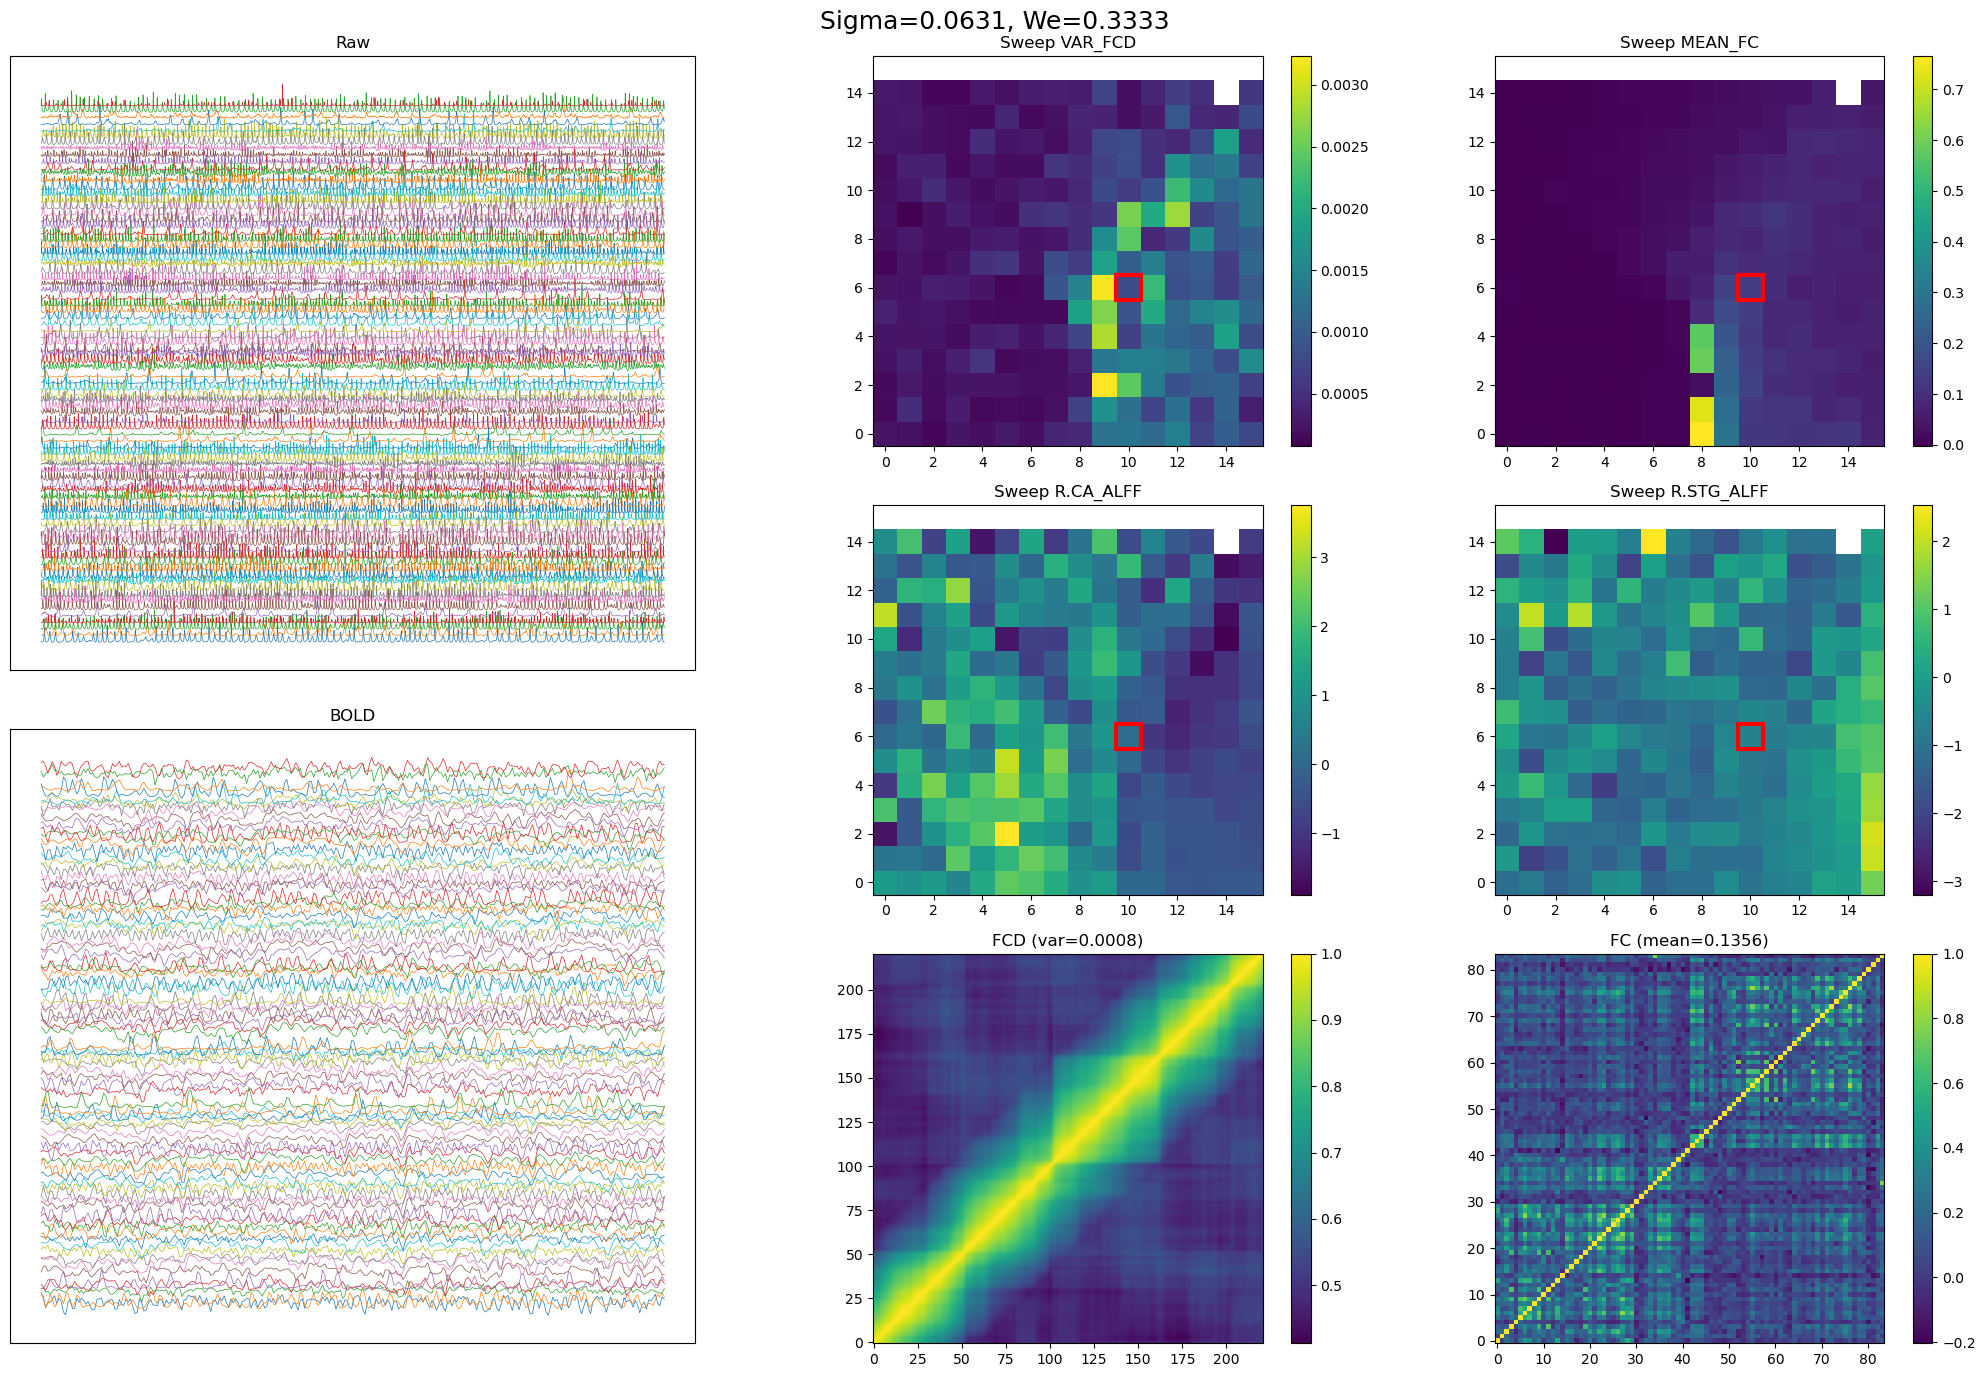

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from synth_pat.scripts.analysis_utils import compute_fcd, fcd_variance_excluding_overlap
from synth_pat.paths import Paths

type_of_sweep =  "restricted_sigma_we"
bold_file = f"{Paths.RESULTS}/{type_of_sweep}_sweep.npz"
feat_file = f"{Paths.RESULTS}/{type_of_sweep}_extracted_features.csv"
feat_df = pd.read_csv(feat_file, index_col=0)
bolds = np.load(bold_file)
bold = bolds['bold']
raw = bolds['raw']

import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Helpers
# ==========================

def minmaxscale(signal):
    smin = signal.min(axis=0)
    smax = signal.max(axis=0)
    return (signal - smin) / (smax - smin + 1e-12)

def stacked_timeseries(ax, signal, title):
    signal = np.array(signal)
    signal = minmaxscale(signal)

    n_regions = signal.shape[1]
    offset = 3

    ax.plot(
        np.arange(signal.shape[0])[:, None],
        10*signal + offset * np.arange(n_regions),
        linewidth=0.5
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

def pivot_metric(metric):
    return feat_df.pivot(
        columns="we",
        index="sigma",
        values=metric
    )

def plot_heatmap(ax, data, title, highlight=True):
    im = ax.imshow(
        data.values,
        origin="lower",
        aspect="equal"   # square
    )
    ax.set_title(title)

    if highlight:
        ax.add_patch(
            plt.Rectangle(
                (col_idx - 0.5, row_idx - 0.5),
                1, 1,
                fill=False,
                edgecolor='red',
                linewidth=3
            )
        )

    return im


# ==========================
# Select parameter set
# ==========================

selected_we = 0.3333 
selected_sigma = 0.0631

idx = np.intersect1d(
    np.where(feat_df['we'] == selected_we),
    np.where(feat_df['sigma'] == selected_sigma)
)[0]

bold_sel = bold[:, :84, idx]
raw_sel = raw[:, :84, idx]

# ==========================
# Compute FC & FCD
# ==========================

window_length = 60
overlap = 59

fc = np.corrcoef(bold_sel.T)
fc_mean = np.mean(fc[np.triu_indices_from(fc, k=1)])

fcd = compute_fcd(bold_sel, window_length=window_length, overlap=overlap)
fcd_3d = fcd[..., None]

fcd_var = fcd_variance_excluding_overlap(
    fcd_3d,
    window_length=window_length,
    overlap=overlap
)

# ==========================
# Sweep maps
# ==========================

varfcd_map = pivot_metric("VAR_FCD")
meanfc_map = pivot_metric("GBC")
alff_ca_map = pivot_metric("R.CA_ALFF")
alff_stg_map = pivot_metric("R.STG_ALFF")

col_idx = np.where(varfcd_map.columns == selected_we)[0][0]
row_idx = np.where(varfcd_map.index == selected_sigma)[0][0]

# ==========================
# Figure Layout
# ==========================

fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(
    6, 3,
    width_ratios=[1.2, 1, 1],
    height_ratios=[1,1,1,1,1,1]
)

# LEFT COLUMN (spanning)
ax_raw  = fig.add_subplot(gs[0:3, 0])
ax_bold = fig.add_subplot(gs[3:6, 0])

stacked_timeseries(ax_raw, raw_sel, "Raw")
stacked_timeseries(ax_bold, bold_sel, "BOLD")

# RIGHT SIDE (3 rows × 2 columns)

# Row 1
ax_varfcd = fig.add_subplot(gs[0:2, 1])
ax_meanfc = fig.add_subplot(gs[0:2, 2])

# Row 2
ax_alff_ca  = fig.add_subplot(gs[2:4, 1])
ax_alff_stg = fig.add_subplot(gs[2:4, 2])

# Row 3
ax_fcd = fig.add_subplot(gs[4:6, 1])
ax_fc  = fig.add_subplot(gs[4:6, 2])

# ==========================
# Plot sweep heatmaps
# ==========================

im1 = plot_heatmap(ax_varfcd, varfcd_map, "Sweep VAR_FCD")
im2 = plot_heatmap(ax_meanfc, meanfc_map, "Sweep MEAN_FC")
im3 = plot_heatmap(ax_alff_ca, alff_ca_map, "Sweep R.CA_ALFF")
im4 = plot_heatmap(ax_alff_stg, alff_stg_map, "Sweep R.STG_ALFF")

# ==========================
# Plot matrices (square)
# ==========================

im5 = ax_fcd.imshow(fcd, origin="lower", aspect="equal")
ax_fcd.set_title(f"FCD (var={fcd_var[0]:.4f})")

im6 = ax_fc.imshow(fc, origin="lower", aspect="equal")
ax_fc.set_title(f"FC (mean={fc_mean:.4f})")

# Colorbars (compact)
for ax, im in zip(
    [ax_varfcd, ax_meanfc, ax_alff_ca, ax_alff_stg, ax_fcd, ax_fc],
    [im1, im2, im3, im4, im5, im6]
):
    fig.colorbar(im, ax=ax, fraction=0.046)

# Global title
fig.suptitle(
    f"Sigma={selected_sigma}, We={selected_we}",
    fontsize=18
)

plt.tight_layout()
plt.show()
